## Import

In [5]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import scipy.linalg as linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
#import preprocess


device = 'cuda:2'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data generation

In [6]:
from datasets import NonlinearGaussian, MoG

n, d = 10000, 64                                 # < higher d, higher MI
true_rho = 0.7                                   # < higher rho, higher MI
case = 'MoG'                                      # < choose between ['1a', '1b', '2', '3a', '3b', '3c', 'MoG']

if case != 'MoG':
    dataset = NonlinearGaussian.NonlinearGaussian(n_samples=n, n_dims=d, rho=true_rho, mu=0, case=case)
    X0, Y0 = dataset.sample_data(n_samples = n)
    X, Y = dataset.transformation(X0, Y0)
    MI = dataset.true_mutual_info()              # we know GT MI
else:
    dataset = MoG.MoG(n_samples=n, n_dims=d, K=5, shifts=[-0.2, -0.1, 0, 0.3, 0.4], rhos=[-0.3, 0.5, 0.2, 0.4, 0.9])
    X, Y = dataset.sample_data(n_samples = n)
    MI = dataset.empirical_mutual_info()         # MI by MC estimate

X, Y = X.to(device), Y.to(device)
Z = torch.cat([X, Y], dim=1)
T = torch.ones(n, 2).to(device)

print('X size=', X.size(), 'Y size=', Y.size())
print("True MI is", MI)

X size= torch.Size([10000, 32]) Y size= torch.Size([10000, 32])
True MI is 6.8805554478134585


## Train the VCE estimator

In [7]:
class Hyperparams(object):
    def __init__(self): 
        self.critic = 'neural'                # ('neural', 'quadratic')
        self.lr = 5e-4
        self.bs = 500
        self.n_bridges = 4
        self.wd = 1e-5
        self.max_iteration = 1250
        
hyperparams=Hyperparams()

architecture_critic = [d, 500, 500, 500, 1]

In [8]:
## Neural adaptive MI estimate
from estimators.VCE import VCE

estimator = VCE(None, None, architecture_critic, hyperparams)
estimator.to(device)
estimator.learn(X, Y)

print('true MI:', MI)
print('est MI:', estimator.MI(X, Y))

K components= 5 copula transform= True
nde type: FM
finished: t= 0 loss= 2.018056631088257 loss val= 2.0351624488830566 best val loss= 2.0351624488830566 best t= 0
finished: t= 126 loss= 1.6396597623825073 loss val= 1.6430952548980713 best val loss= 1.620300531387329 best t= 43


finished: t= 0 loss= 2.0757739543914795 loss val= 2.066169261932373 best val loss= 2.066169261932373 best t= 0
finished: t= 126 loss= 1.6644246578216553 loss val= 1.653496503829956 best val loss= 1.625997543334961 best t= 59
finished: t= 252 loss= 1.6596657037734985 loss val= 1.6604204177856445 best val loss= 1.625997543334961 best t= 59


finished: t= 0 loss= 441.1421203613281 loss val= 442.72760009765625 best val loss= 442.72760009765625 best t= 0
finished: t= 101 loss= 84.83525085449219 loss val= 85.53875732421875 best val loss= 85.53094482421875 best t= 75
finished: t= 202 loss= 84.63203430175781 loss val= 85.56143188476562 best val loss= 85.53094482421875 best t= 75


K components= 5 finished
true MI: 6.8

### Check the computed vector ranks

In [9]:
import torch.distributions as distribution

XX, YY = estimator.forward(X, Y)

# Compute empirical ranks
sorted_data, idx = torch.sort(XX, dim=0)
_, idx2 = torch.sort(idx, dim=0)
U = (idx2.float()+1)/(len(XX)+1)   

# Compute covariance
zeros, ones = torch.zeros(XX.size()).to(XX.device), torch.ones(XX.size()).to(XX.device)
U = (U-U.mean(keepdim=True, dim=0))/U.std(keepdim=True, dim=0)


V = torch.matmul(U.t(), U)/(len(U)+1)

### Visualizing the distributions of non-diagonal elements

mean abs 0.021135553879144203
q5 -0.03486694023013115
q95 0.03404509648680687


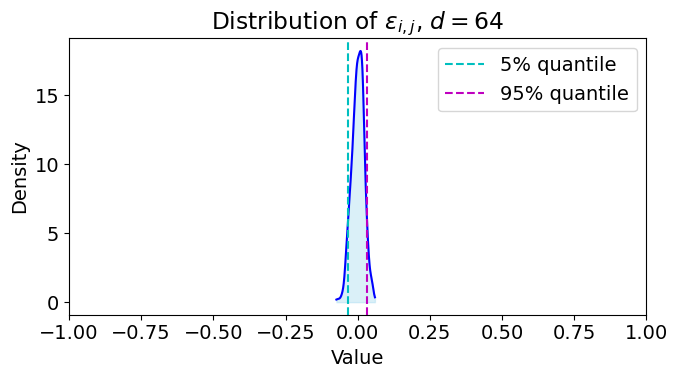

In [10]:
from scipy.stats import gaussian_kde


# Set global font size
plt.rcParams.update({'font.size': 14})

# Get non-diagonal elements of covariance matrices
non_diag_mask = ~torch.eye(V.size(0), dtype=bool, device=V.device)
non_diag_values = V[non_diag_mask]

# Convert to numpy
non_diag_np = non_diag_values.cpu().numpy()
sorted_vals = np.sort(non_diag_np)

# Compute ranks
L = len(sorted_vals)
q5, q95 = sorted_vals[int(L * 0.05)], sorted_vals[int(L * 0.95)]
print('mean abs', (sorted_vals**2).mean()**0.5)
print('q5', q5.item())
print('q95', q95.item())

# KDE with scipy
kde = gaussian_kde(non_diag_np)
x_vals = np.linspace(min(non_diag_np), max(non_diag_np), 1000)
density = kde(x_vals)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(x_vals, density, color='blue')
plt.fill_between(x_vals, density, alpha=0.3, color='skyblue')
plt.axvline(q5, color='c', linestyle='--', label='5% quantile')
plt.axvline(q95, color='m', linestyle='--', label='95% quantile')
plt.title(r'Distribution of $\epsilon_{i, j}$, $d=64$')
plt.xlim(-1, 1)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('vector_rank_quality_MoG_64D.png', dpi=300)
plt.show()